In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("titanic_sample_1000.csv")
dataset.head(3)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,1,2,male,21.0,0,0,40.82,S
1,2,0,3,male,17.0,1,0,10.52,S
2,3,0,3,female,23.0,1,0,12.33,S


In [3]:
dataset.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            190
SibSp            0
Parch            0
Fare             0
Embarked         3
dtype: int64

In [6]:
dataset["Age"] = dataset["Age"].fillna(dataset["Age"].mean())

In [7]:
dataset.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       3
dtype: int64

In [9]:
np.percentile(dataset["Age"],25), np.percentile(dataset["Age"],75)

(np.float64(22.75), np.float64(35.0))

In [12]:
dataset["Age"].min() , dataset["Age"].max()

(np.float64(1.0), np.float64(66.0))

In [14]:
np.percentile(dataset["Age"],50) , dataset["Age"].median()

(np.float64(29.18641975308642), np.float64(29.18641975308642))

Either we can findout the median of data or 50 percentile of data in both the cases the number should be same.


In [15]:
dataset.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,1000.000000,1000.000000,1000.00000,1000.00000,1000.000000,1000.00000,1000.000000
mean,500.500000,0.302000,2.28400,29.18642,0.438000,0.36000,39.147900
std,288.819436,0.459355,0.84502,10.54239,0.805484,0.73276,49.681657
min,1.000000,0.000000,1.00000,1.00000,0.000000,0.00000,4.530000
25%,250.750000,0.000000,1.00000,22.75000,0.000000,0.00000,10.397500
50%,500.500000,0.000000,3.00000,29.18642,0.000000,0.00000,17.385000
75%,750.250000,1.000000,3.00000,35.00000,1.000000,0.00000,47.207500
max,1000.000000,1.000000,3.00000,66.00000,4.000000,3.00000,512.330000


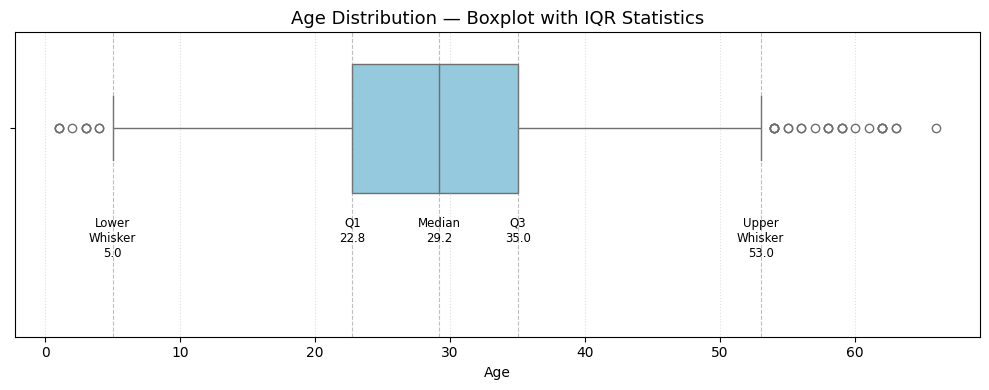

In [17]:
Q1 = dataset["Age"].quantile(0.25)
Q3 = dataset["Age"].quantile(0.75)
IQR = Q3 - Q1
median = dataset["Age"].median()
lower_whisker = dataset["Age"][dataset["Age"] >= Q1 - 1.5 * IQR].min()
upper_whisker = dataset["Age"][dataset["Age"] <= Q3 + 1.5 * IQR].max()

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x="Age", data=dataset, color="skyblue", ax=ax)

stats = {
    "Lower\nWhisker": lower_whisker,
    "Q1": Q1,
    "Median": median,
    "Q3": Q3,
    "Upper\nWhisker": upper_whisker,
}

ax.set_ylim(-1.3, 0.6)
for label, value in stats.items():
    ax.axvline(value, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.text(value, -0.55, f"{label}\n{value:.1f}", ha="center", va="top", fontsize=8.5)

ax.set_title("Age Distribution — Boxplot with IQR Statistics", fontsize=13)
ax.set_xlabel("Age")
ax.grid(axis="x", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

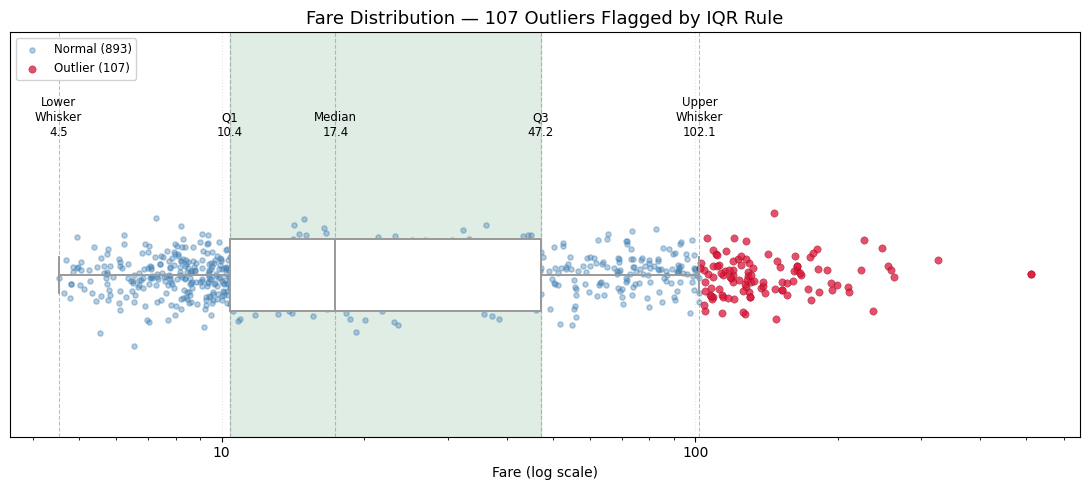

In [19]:
import matplotlib.ticker as mticker

Q1 = dataset["Fare"].quantile(0.25)
Q3 = dataset["Fare"].quantile(0.75)
IQR = Q3 - Q1
median = dataset["Fare"].median()
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
lower_whisker = dataset["Fare"][dataset["Fare"] >= lower_bound].min()
upper_whisker = dataset["Fare"][dataset["Fare"] <= upper_bound].max()
is_outlier = (dataset["Fare"] < lower_bound) | (dataset["Fare"] > upper_bound)

rng = np.random.default_rng(42)
y_jitter = rng.normal(0, 0.06, size=len(dataset))

fig, ax = plt.subplots(figsize=(11, 5))

# Shade the IQR band
ax.axvspan(Q1, Q3, color="seagreen", alpha=0.15, zorder=0)

# Jittered strip of every fare, colored by outlier status
ax.scatter(dataset["Fare"][~is_outlier], y_jitter[~is_outlier], s=14, alpha=0.4,
           color="steelblue", label=f"Normal ({(~is_outlier).sum()})", zorder=1)
ax.scatter(dataset["Fare"][is_outlier], y_jitter[is_outlier], s=28, alpha=0.75,
           color="crimson", edgecolor="darkred", linewidth=0.3,
           label=f"Outlier ({is_outlier.sum()})", zorder=2)

# Boxplot drawn on top, narrow and white so the points underneath still read
sns.boxplot(x=dataset["Fare"], ax=ax, width=0.22, color="white", linewidth=1.4,
            fliersize=0, zorder=3)

stats = {
    "Lower\nWhisker": lower_whisker,
    "Q1": Q1,
    "Median": median,
    "Q3": Q3,
    "Upper\nWhisker": upper_whisker,
}
for label, value in stats.items():
    ax.axvline(value, color="gray", linestyle="--", linewidth=0.8, alpha=0.5, zorder=0)
    ax.text(value, 0.42, f"{label}\n{value:.1f}", ha="center", va="bottom", fontsize=8.5)

ax.set_xscale("log")
ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(mticker.NullFormatter())

ax.set_ylim(-0.5, 0.75)
ax.set_yticks([])
ax.set_xlabel("Fare (log scale)")
ax.set_title(f"Fare Distribution — {is_outlier.sum()} Outliers Flagged by IQR Rule", fontsize=13)
ax.legend(loc="upper left", fontsize=8.5, framealpha=0.9)
ax.grid(axis="x", which="major", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()